# Tutorial: Querying the NORDCAN API & Building Interactive Trend Charts

Welcome to this hands-on tutorial on the **NORDCAN REST API (v9.6)**.

In this notebook, you will learn how to interact directly with the cancer registry API of the Nordic countries, retrieve longitudinal cancer epidemiology data, and build a publication-grade interactive **Plotly trend chart** with rich tooltips, direct line labels, and downloadable data.

---

### Workshop Learning Objectives:
1. **Understand REST API Endpoints**: Learn how URL path parameters encode registry, sex, data type (incidence vs mortality), and cancer sites.
2. **Metadata Discovery**: Query metadata endpoints to dynamically translate human names into numeric API identifiers.
3. **Query Construction**: Bundle multi-site queries into a single efficient HTTP GET request.
4. **Data Transformation**: Clean and structure JSON payloads into a pandas `DataFrame`.
5. **Epidemiological Ranking**: Identify and filter the **Top 10 cancer mortality sites for females in Finland**.
6. **Publication-Ready Visualization**: Create an interactive **Plotly trendline chart** with direct endpoint labels and custom hover tooltips.
7. **Data Export**: Export and download the curated dataset as a CSV file.

---

### Setup & Dependencies
Run the cell below to load packages (auto-detects Google Colab or local JupyterLab).

In [1]:
# 1. Environment Setup
try:
    import google.colab
    IN_COLAB = True
    %pip install -q requests pandas plotly itables ipywidgets
except ImportError:
    IN_COLAB = False

In [2]:
import json
import base64
import requests
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display, HTML
from itables import init_notebook_mode

init_notebook_mode(all_interactive=True)
print(f"Setup complete. Google Colab: {IN_COLAB} | Pandas: {pd.__version__}")


Setup complete. Google Colab: False | Pandas: 3.0.5


## Step 1: NORDCAN REST API Architecture

The **NORDCAN API** exposes public REST endpoints provided by the International Agency for Research on Cancer (IARC) and NORDCAN.

**Base URL**: `https://gco-api.iarc.fr/api/nordcan/v4/96/`

### Primary Data Endpoint Structure:
```text
https://gco-api.iarc.fr/api/nordcan/v4/96/data/population/{type}/{sex}/{population}/{cancer}/
```

| Parameter | Type | Allowed Values & Description |
| :--- | :---: | :--- |
| `type` | Integer | `0` = Incidence (New cases), `1` = Mortality (Deaths) |
| `sex` | Integer | `0` = Both sexes, `1` = Male, `2` = Female |
| `population` | Integer | Country or regional registry ID (e.g. `246` = Finland, `578` = Norway) |
| `cancer` | String | Cancer ID(s). **Multiple IDs can be bundled using underscores `_`** (e.g. `160_180_130`) |

Let's test this in Python.

In [3]:
BASE_URL = "https://gco-api.iarc.fr/api/nordcan/v4/96"
print(f"Base API Endpoint: {BASE_URL}")

Base API Endpoint: https://gco-api.iarc.fr/api/nordcan/v4/96


## Step 2: Discovering Metadata (Populations & Cancers)

Before fetching cancer statistics, we need to know the numeric identifiers for:
1. **Finland**
2. **All leaf (mutually exclusive) cancer sites**

Let's query the metadata endpoints:
- Populations metadata: `https://gco-api.iarc.fr/api/nordcan/v4/96/meta/populations/all/`
- Cancers metadata: `https://gco-api.iarc.fr/api/nordcan/v4/96/meta/cancers/all/`

In [4]:
# Fetch population metadata
pop_resp = requests.get(f"{BASE_URL}/meta/populations/all/").json()
pop_lookup = {}
for p in pop_resp:
    pid = p.get("country") if p.get("country") is not None else p.get("country_code")
    pop_lookup[pid] = p.get("label")

# Fetch cancer metadata (labels & official color scheme)
cancers_meta = requests.get(f"{BASE_URL}/meta/cancers/all/").json()
cancer_lookup = {c["id"]: c for c in cancers_meta}

sex_lookup = {0: "both sexes", 1: "male", 2: "female"}
type_lookup = {0: "incidence", 1: "mortality"}

print(f"Total Populations in NORDCAN: {len(pop_lookup)}")
print(f"Total Cancer Entities in NORDCAN: {len(cancer_lookup)}")

Total Populations in NORDCAN: 31
Total Cancer Entities in NORDCAN: 65


In [5]:
pop_lookup

{0: 'NORDCAN countries',
 1: 'NORDCAN countries excl. Faroe Islands and Greenland',
 208: 'Denmark',
 234: 'Faroe Islands',
 246: 'Finland',
 304: 'Greenland',
 352: 'Iceland',
 578: 'Norway',
 752: 'Sweden',
 2080: 'DK, North Jutland',
 2081: 'DK, Central Jutland',
 2082: 'DK, Southern Denmark',
 2083: 'DK, Greater Copenhagen',
 2084: 'DK, Zealand',
 2460: 'FI, Southern Finland',
 2461: 'FI, Western Finland and Åland',
 2462: 'FI, Inland Finland',
 2463: 'FI, Eastern Finland',
 2464: 'FI, Northern Finland',
 3520: 'IS, Reykjavik-Reykjanes',
 3521: 'IS, Rural',
 5780: 'NO, Southeastern',
 5781: 'NO, Western',
 5782: 'NO, Central',
 5783: 'NO, Northern',
 7520: 'SE, Stockholm-Gotland',
 7521: 'SE, Uppsala-Örebro',
 7522: 'SE, Southeastern',
 7523: 'SE, Southern',
 7524: 'SE, Western',
 7525: 'SE, Northern'}

In [6]:
# Find Finland ID
finland_id = next(pid for pid, name in pop_lookup.items() if name == "Finland")
print(f"Target Population: Finland -> ID = {finland_id}")

Target Population: Finland -> ID = 246


## Step 3: Defining Leaf Cancer Sites

In cancer registries, some cancer IDs represent broad grouped categories (e.g. *All cancers combined* or *Digestive organs*), while others represent **mutually exclusive leaf cancer sites** (e.g. *Stomach*, *Colon*, *Rectum*, *Pancreas*, *Lung*, *Breast*).

To analyze all distinct cancer sites without double-counting, we bundle the **55 standard leaf cancer IDs** into our query.

In [7]:
# Official 55 leaf cancer site IDs in NORDCAN
LEAF_CANCER_IDS = [
    10, 20, 30, 40, 41, 50, 60, 70, 80, 90, 100, 105, 110, 120, 130, 
    140, 150, 160, 170, 180, 190, 200, 210, 220, 227, 228, 229, 240, 
    250, 260, 270, 280, 290, 300, 310, 316, 315, 330, 340, 350, 360, 
    370, 380, 390, 392, 394, 401, 402, 403, 404, 405, 406, 407, 410, 420
]

# Clean label helper
SHORT_NAMES = {
    "Skin, non-melanoma, excl. basal cell carcinomas": "Non-melanoma skin",
    "Brain and CNS including endocrine tumors": "Brain & CNS (incl. endo)",
    "Brain and CNS excluding endocrine tumors": "Brain & CNS",
    "Lip, oral cavity and pharynx": "Lip, oral & pharynx",
    "Bladder and urinary tract": "Bladder & urinary tract",
    "Other and ill-defined cancers": "Other / ill-defined",
    "Other specified cancers": "Other specified",
    "Malignant haematopoietic diseases": "Malignant haematopoietic",
    "Non Hodgkin lymphomas": "Non-Hodgkin lymphoma",
    "Hodgkin lymphomas": "Hodgkin lymphoma",
    "Multiple myelomas": "Multiple myeloma",
    "Myeloproliferative diseases": "Myeloproliferative",
    "Myelodysplastic syndromes": "Myelodysplastic",
    "Nasal Cavity, middle ear and sinuses": "Nasal cavity & sinuses",
    "Vulva, vagina and other female genital organs": "Vulva/vagina/other fem.",
    "Penis and other male genital organs": "Penis/other male gen."
}

def get_cancer_name(cid):
    if cid in cancer_lookup:
        lbl = cancer_lookup[cid]["label"]
        return SHORT_NAMES.get(lbl, lbl)
    return f"Cancer {cid}"

def get_cancer_color(cid):
    if cid in cancer_lookup and "color" in cancer_lookup[cid]:
        return cancer_lookup[cid]["color"]
    return "#3366CC"

print(f"Prepared {len(LEAF_CANCER_IDS)} leaf cancer sites.")

Prepared 55 leaf cancer sites.


## Step 4: Constructing & Executing the API Query

Now we construct the exact URL to fetch:
- **Type**: `1` (*Mortality*)
- **Sex**: `2` (*Female*)
- **Population**: `246` (*Finland*)
- **Cancers**: All 55 leaf IDs bundled with underscores (`10_20_30_...`)

In [8]:
# Bundle leaf IDs with '_'
cancer_param = "_".join(map(str, LEAF_CANCER_IDS))

# Construct request URL
data_type = 1  # 1 = Mortality
sex = 2        # 2 = Female
pop_id = 246   # 246 = Finland

request_url = f"{BASE_URL}/data/population/{data_type}/{sex}/{pop_id}/{cancer_param}/"

print("Generated NORDCAN Request URL:")
print(request_url)

# Execute HTTP GET request
print("Sending request to NORDCAN API...")
response = requests.get(request_url)
print(f"Status Code: {response.status_code} ({'OK' if response.status_code == 200 else 'FAILED'})")

# Parse JSON
raw_json = response.json()
raw_dataset = raw_json["dataset"]
print(f"Received {len(raw_dataset):,} annual record entries.")


Generated NORDCAN Request URL:
https://gco-api.iarc.fr/api/nordcan/v4/96/data/population/1/2/246/10_20_30_40_41_50_60_70_80_90_100_105_110_120_130_140_150_160_170_180_190_200_210_220_227_228_229_240_250_260_270_280_290_300_310_316_315_330_340_350_360_370_380_390_392_394_401_402_403_404_405_406_407_410_420/
Sending request to NORDCAN API...
Status Code: 200 (OK)
Received 3,744 annual record entries.


## Step 5: Structuring into a Pandas DataFrame

Let's convert the JSON records into a structured pandas `DataFrame` and annotate each record with:
- **`cancer_label`**: Clean, human-readable cancer name
- **`color`**: Official NORDCAN color hex code

In [9]:
df = pd.DataFrame(raw_dataset)

# Add human labels and colors
df["cancer_label"] = df["cancer"].apply(get_cancer_name)
df["color"] = df["cancer"].apply(get_cancer_color)

# Ensure numeric columns are properly typed
numeric_cols = ["year", "cancer", "total", "crude_rate", "asr", "cum_risk_74"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

min_yr = int(df["year"].min())
max_yr = int(df["year"].max())

print(f"DataFrame Shape : {df.shape}")
print(f"Time Range      : {min_yr} to {max_yr} ({max_yr - min_yr + 1} years)")
print(f"Unique Cancers  : {df['cancer_label'].nunique()}")

# Preview first 5 rows
df[["year", "cancer", "cancer_label", "total", "crude_rate", "asr", "cumulative_risk_74"]].head()


DataFrame Shape : (3744, 23)
Time Range      : 1953 to 2024 (72 years)
Unique Cancers  : 52


year  cancer     cancer_label      total  crude_rate       asr  \
0  1953      10              Lip   1.714286    0.079445  0.081316   
1  1953      20      Oral Cavity  15.714286    0.728250  0.661459   
2  1953      30  Salivary glands   6.142857    0.284680  0.273168   
3  1953      40       Oropharynx   5.285714    0.244957  0.205820   
4  1953      41      Nasopharynx   3.285714    0.152270  0.133900   

   cumulative_risk_74  
0            0.004690  
1            0.076922  
2            0.029074  
3            0.028754  
4            0.011612

## Step 6: Identifying the Top 10 Cancer Mortality Sites (Latest Year)

Let's rank all cancer causes of death for Finnish females in the most recent year (`2024`) by **Crude Mortality Rate** (deaths per 100,000 females).

In [10]:
latest_year = int(df["year"].max())

# Filter for latest year and sort descending by crude rate
latest_df = df[df["year"] == latest_year].sort_values("crude_rate", ascending=False).reset_index(drop=True)
latest_df["rank"] = range(1, len(latest_df) + 1)

# Select Top 10
top10_latest = latest_df.head(10)

print(f"=== TOP 10 CANCER CAUSES OF DEATH IN FINLAND (FEMALES, {latest_year}) ===")
for _, row in top10_latest.iterrows():
    print(f"#{row['rank']:2d} | {row['cancer_label']:<28} | Crude Rate: {row['crude_rate']:5.1f} per 100k | Deaths: {int(row['total']):,d}")

top10_cancer_names = top10_latest["cancer_label"].tolist()

# Filter full dataset for top 10 cancers
df_top10 = df[df["cancer_label"].isin(top10_cancer_names)].copy()
df_top10 = df_top10.sort_values(["cancer_label", "year"]).reset_index(drop=True)

print(f"\nFiltered {len(df_top10):,} annual records for the top 10 cancer sites ({min_yr}–{max_yr}).")
print(f"(Instead of using our downloaded data, we could get this data directly by accessing: {BASE_URL}/data/population/{data_type}/{sex}/{pop_id}/{'_'.join(df_top10['cancer'].unique().astype('str'))}/ )")

=== TOP 10 CANCER CAUSES OF DEATH IN FINLAND (FEMALES, 2024) ===
# 1 | Breast                       | Crude Rate:  31.6 per 100k | Deaths: 897
# 2 | Lung                         | Crude Rate:  29.9 per 100k | Deaths: 848
# 3 | Pancreas                     | Crude Rate:  23.2 per 100k | Deaths: 658
# 4 | Colon                        | Crude Rate:  16.8 per 100k | Deaths: 476
# 5 | Ovary and tubes              | Crude Rate:  12.5 per 100k | Deaths: 355
# 6 | Other / ill-defined          | Crude Rate:  11.5 per 100k | Deaths: 326
# 7 | Non-Hodgkin lymphoma         | Crude Rate:   8.4 per 100k | Deaths: 239
# 8 | Corpus uteri                 | Crude Rate:   7.3 per 100k | Deaths: 207
# 9 | Rectum                       | Crude Rate:   6.6 per 100k | Deaths: 187
#10 | Gallbladder                  | Crude Rate:   6.2 per 100k | Deaths: 176

Filtered 720 annual records for the top 10 cancer sites (1953–2024).
(Instead of using our downloaded data, we could get this data directly by accessing: 

## Step 7: Building the Interactive Plotly Trend Chart

We will now build an interactive **Plotly trend chart** corresponding to the final frame of the trendlines animation:
- **Smooth lines** colored according to official NORDCAN color definitions.
- **Direct line endpoint annotations**: Each curve is labeled right at its terminal point (year 2024) so readers don't need to cross-reference a disconnected legend.
- **Enhanced custom hover tooltips**: Displays **Cancer Site**, **Year**, **Crude Mortality Rate (per 100k)**, and **Total Annual Deaths**.
- **Interactive Plotly toolbar**: Zoom, pan, reset, box select, and download as PNG.

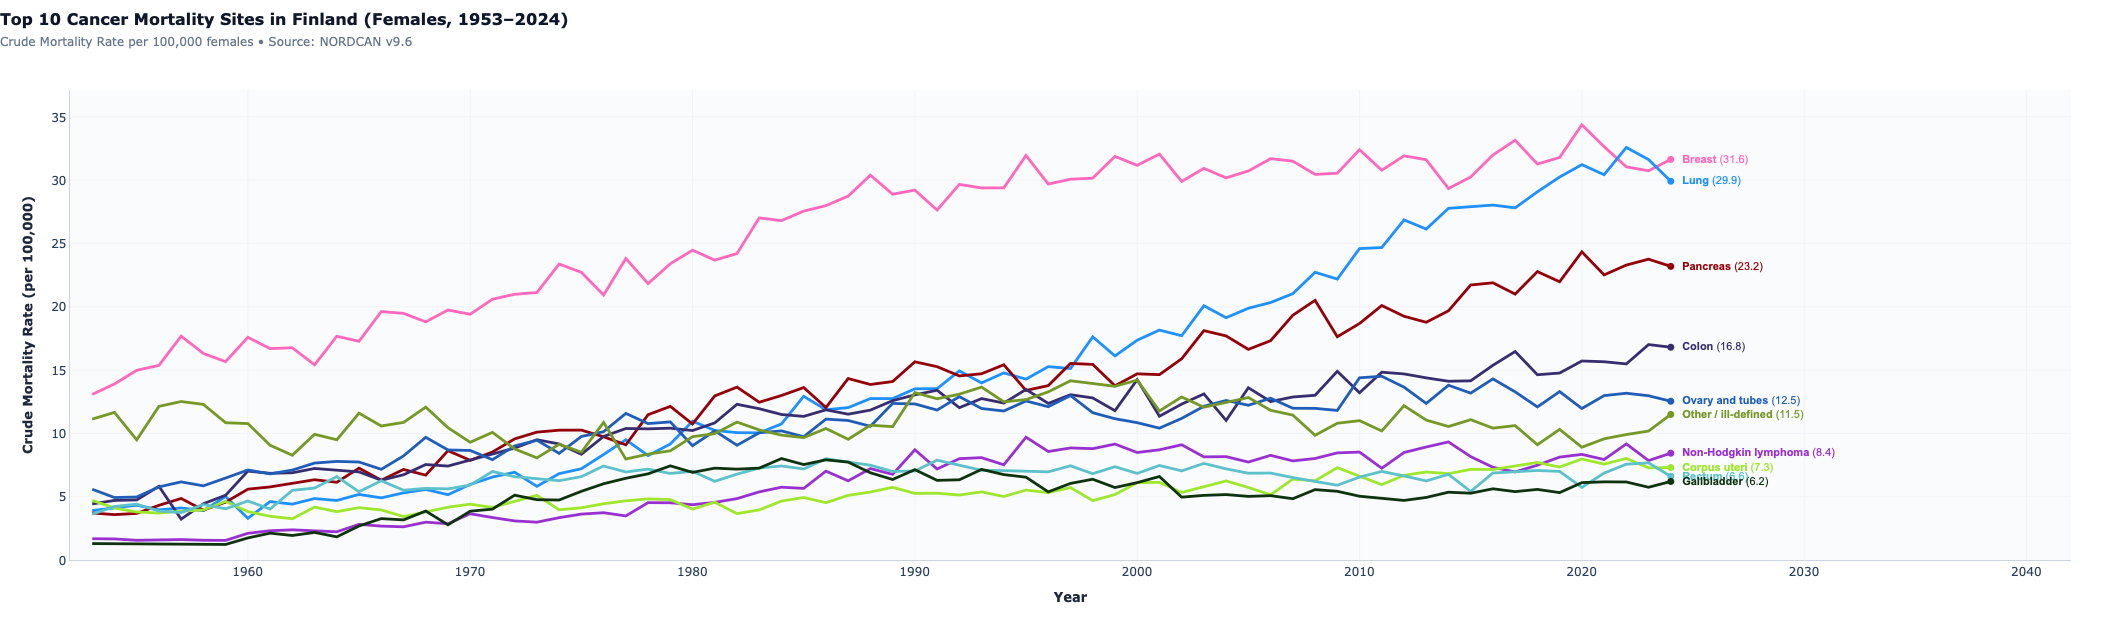

In [11]:
# Create Plotly Figure
fig = go.Figure()

# Track unique cancer colors
color_map = {row["cancer_label"]: row["color"] for _, row in df_top10.drop_duplicates("cancer_label").iterrows()}

# Add a trace for each cancer site
for cname in top10_cancer_names:
    csub = df_top10[df_top10["cancer_label"] == cname].sort_values("year")
    if len(csub) == 0:
        continue
        
    color = color_map.get(cname, "#2563eb")
    last_pt = csub.iloc[-1]
    
    # 1. Main Trend Line
    fig.add_trace(go.Scatter(
        x=csub["year"],
        y=csub["crude_rate"],
        mode="lines",
        name=cname,
        line=dict(color=color, width=2.8),
        customdata=list(zip(csub["total"], csub["asr"])),
        hovertemplate=(
            f"<b>{cname}</b><br>"
            "Year: <b>%{x}</b><br>"
            "Crude Mortality Rate: <b>%{y:.1f}</b> per 100k<br>"
            "Total Deaths: <b>%{customdata[0]:,d}</b><br>"
            "ASR (World): <b>%{customdata[1]:.1f}</b> per 100k<extra></extra>"
        ),
        showlegend=False
    ))
    
    # 2. Endpoint Marker + Text Label (Pinned to 2023)
    fig.add_trace(go.Scatter(
        x=[last_pt["year"]],
        y=[last_pt["crude_rate"]],
        mode="markers+text",
        name=cname,
        marker=dict(color=color, size=7, symbol="circle"),
        text=[f"  <b>{cname}</b> ({last_pt['crude_rate']:.1f})"],
        textposition="middle right",
        textfont=dict(size=11, color=color, family="Arial, sans-serif"),
        hoverinfo="skip",
        showlegend=False
    ))

# Layout Configuration
fig.update_layout(
    title=dict(
        text=f"<b>Top 10 Cancer Mortality Sites in Finland (Females, {min_yr}–{max_yr})</b><br><span style='font-size:12px; color:#64748b;'>Crude Mortality Rate per 100,000 females • Source: NORDCAN v9.6</span>",
        x=0.0,
        y=0.96,
        font=dict(size=16, color="#0f172a")
    ),
    xaxis=dict(
        title=dict(text="<b>Year</b>", font=dict(size=13, color="#1e293b")),
        range=[min_yr - 1, max_yr + 18],  # Extra space on right for direct endpoint labels
        dtick=10,
        gridcolor="#f1f5f9",
        showline=True,
        linecolor="#cbd5e1"
    ),
    yaxis=dict(
        title=dict(text="<b>Crude Mortality Rate (per 100,000)</b>", font=dict(size=13, color="#1e293b")),
        range=[0, df_top10["crude_rate"].max() * 1.08],
        gridcolor="#f1f5f9",
        showline=True,
        linecolor="#cbd5e1"
    ),
    paper_bgcolor="white",
    plot_bgcolor="#fafbfc",
    hovermode="closest",
    height=620,
    margin=dict(l=70, r=40, t=90, b=60)
)

fig.show()


## Step 8: Exporting and Downloading Data

You can save the curated dataset locally as a CSV file, or click the download button below to save it directly to your computer.

In [12]:
# 1. Save to local disk
csv_filename = f"{pop_lookup[pop_id]}_{sex_lookup[sex]}_cancer_{type_lookup[data_type]}_top10.csv"
export_df = df_top10[["year", "cancer", "cancer_label", "total", "crude_rate", "asr", "cumulative_risk_74"]].copy()
export_df.to_csv(csv_filename, index=False)
print(f"Successfully saved '{csv_filename}' ({len(export_df):,} rows)")

# 2. Interactive In-Browser Download Button
csv_str = export_df.to_csv(index=False)
b64 = base64.b64encode(csv_str.encode()).decode()

download_html = f'''
<div style="margin: 15px 0; padding: 16px; background: #f8fafc; border: 1px solid #e2e8f0; border-radius: 8px; font-family: sans-serif;">
    <h4 style="margin: 0 0 8px 0; color: #0f172a;">Download Curated Dataset:</h4>
    <p style="margin: 0 0 12px 0; font-size: 13px; color: #64748b;">
        Contains annual counts, crude rates, ASR (World), and cumulative risk for the top 10 cancer {type_lookup[data_type]} sites in {pop_lookup[pop_id]}, {sex_lookup[sex]} ({min_yr}–{max_yr}).
    </p>
    <a download="{csv_filename}" href="data:text/csv;base64,{b64}" target="_blank" 
       style="display: inline-block; background: #2563eb; color: white; padding: 9px 18px; border-radius: 6px; text-decoration: none; font-weight: 600; font-size: 13px;">
       Download {csv_filename}
    </a>
</div>
'''

display(HTML(download_html))


Successfully saved 'Finland_female_cancer_mortality_top10.csv' (720 rows)


## Step 9: Interactive Searchable Table (itables)

Explore, filter, and sort the complete dataset interactively in the table below:

In [13]:
export_df.sort_values(["year", "crude_rate"], ascending=[False, False])

year  cancer          cancer_label       total  crude_rate        asr  \
71   2024     180                Breast  897.800000   31.639681  10.793323   
359  2024     160                  Lung  848.800000   29.912855   8.997172   
647  2024     130              Pancreas  658.000000   23.188806   6.530464   
143  2024      90                 Colon  476.800000   16.803074   4.273925   
575  2024     220       Ovary and tubes  355.800000   12.538871   3.973322   
..    ...     ...                   ...         ...         ...        ...   
288  1953     160                  Lung   84.285714    3.906068   3.473693   
576  1953     130              Pancreas   80.142857    3.714075   3.392119   
648  1953     100                Rectum   78.142857    3.621388   3.313111   
360  1953     360  Non-Hodgkin lymphoma   36.285714    1.681595   1.568880   
216  1953     120           Gallbladder   28.000000    1.297609   1.150678   

     cumulative_risk_74  
71             1.125750  
359            1.108019  
647            0.695382  
143            0.426830  
575            0.447644  
..                  ...  
288            0.410602  
576            0.362789  
648            0.368963  
360            0.171141  
216            0.148651  

[720 rows x 7 columns]

## References & Official Citation

- **Explore on NORDCAN Portal**: [NORDCAN Trend Visualizer](https://nordcan.iarc.fr/en/dataviz/trends?group_populations=0&multiple_cancers=1&cancers=180_90_200_120_160_360_420_220_130_100&sexes=2&populations=246&types=1&key=crude_rate&mode=cancer&multiple_populations=0)

### Mandatory Citation:
> Larønningen S, Arvidsson G, Bray F, Dahl-Olsen ED, Engholm G, Ervik M, Friis S, Guðmundsdóttir EM, Gulbrandsen J, Hansen HM, Johannesen TB, Kristensen S, Kønig SM, Lam F, Laversanne M, Lydersen LN, Malila N, Mangrud OM, Miettinen J, Pejicic S, Persson Å, Pettersson D, Skog A, Steig BÁ, Tian H, Aagnes B, Storm HH (2026). NORDCAN: Cancer Incidence, Mortality, Prevalence and Survival in the Nordic Countries, Version 9.5.1 (12.02.2026). Association of the Nordic Cancer Registries. Cancer Registry of Norway. Available from: https://nordcan.iarc.fr/, accessed on 21/08/2026.
